# UMAP Clustering of ESM2 Protein Embeddings

This notebook loads the CAFA3 merged dataset and performs UMAP dimensionality reduction
on protein embeddings to visualize clustering patterns by taxa and HOG.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

/home/acefsan/src/dl_bio/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-02 21:58:55.802408: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 21:58:56.198072: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load the CAFA3 Merged Dataset

In [2]:
# Load the merged dataset
data_path = Path("../assets/proteins/datasets/cafa3_merged/cafa3_with_embeddings.feather")
print(f"Loading dataset from {data_path}...")
df = pd.read_feather(data_path)
print(f"Loaded {len(df):,} rows, {df['EntryID'].nunique():,} unique proteins")
print(f"\nColumns: {list(df.columns[:12])} ... + {len(df.columns)-12} embedding columns")

Loading dataset from ../assets/proteins/datasets/cafa3_merged/cafa3_with_embeddings.feather...
Loaded 5,363,863 rows, 142,246 unique proteins

Columns: ['EntryID', 'Sequence', 'Length', 'taxonomyID', 'scientific_name', 'common_name', 'oma_id', 'hog_id', 'roothog_id', 'term', 'aspect', 'description'] ... + 1280 embedding columns


In [3]:
# Check available taxa
print("Top 20 species by protein count:")
taxa_counts = df.groupby(['taxonomyID', 'scientific_name'])['EntryID'].nunique().sort_values(ascending=False)
print(taxa_counts.head(20))

Top 20 species by protein count:
taxonomyID  scientific_name                                                                                                  
9606        Homo sapiens                                                                                                         25125
3702        Arabidopsis thaliana                                                                                                 14461
10090       Mus musculus                                                                                                         14384
7955        Danio rerio                                                                                                          12671
7227        Drosophila melanogaster                                                                                              12020
10116       Rattus norvegicus                                                                                                     8817
559292      Saccharomyces cerev

In [4]:
# Find human and octopus taxonomy IDs
print("\nSearching for human and octopus...")
human_mask = df['scientific_name'].str.contains('Homo sapiens', na=False, case=False)
octopus_mask = df['scientific_name'].str.contains('Octopus', na=False, case=False)

if human_mask.any():
    human_taxid = df.loc[human_mask, 'taxonomyID'].iloc[0]
    human_name = df.loc[human_mask, 'scientific_name'].iloc[0]
    print(f"Human: taxonomyID={human_taxid}, name={human_name}")
else:
    print("Human not found, checking alternatives...")
    print(df[df['scientific_name'].str.contains('sapiens', na=False, case=False)]['scientific_name'].unique()[:5])

if octopus_mask.any():
    octopus_taxid = df.loc[octopus_mask, 'taxonomyID'].iloc[0]
    octopus_name = df.loc[octopus_mask, 'scientific_name'].iloc[0]
    print(f"Octopus: taxonomyID={octopus_taxid}, name={octopus_name}")
else:
    print("Octopus not found, checking cephalopods...")
    ceph_mask = df['scientific_name'].str.contains('cephalopod|squid|nautilus', na=False, case=False)
    if ceph_mask.any():
        print(df.loc[ceph_mask, 'scientific_name'].unique()[:5])


Searching for human and octopus...
Human: taxonomyID=9606, name=Homo sapiens
Octopus: taxonomyID=6645, name=Octopus vulgaris


## Filter to Human and Octopus (or alternative species)

In [ ]:
# Define target taxa - adjust if octopus not found
# Common taxonomy IDs: Human=9606, Mouse=10090, Zebrafish=7955, Drosophila=7227
TARGET_TAXA = {
    9606: 'Human',
    3702: 'Drosophila',
}

# Check if octopus was found, otherwise use an interesting alternative
if 'octopus_taxid' in dir() and octopus_taxid:
    TARGET_TAXA[octopus_taxid] = 'Octopus'
else:
    # Use zebrafish as alternative (distant vertebrate)
    TARGET_TAXA[7955] = 'Zebrafish'
    print("Using Zebrafish instead of Octopus")

print(f"Target taxa: {TARGET_TAXA}")

Target taxa: {9606: 'Human', np.int64(6645): 'Octopus'}


In [6]:
# Get unique proteins per taxon (avoid duplicates from multiple GO terms)
embedding_cols = [c for c in df.columns if c.startswith('ME:')]
protein_cols = ['EntryID', 'Sequence', 'Length', 'taxonomyID', 'scientific_name', 
                'oma_id', 'hog_id', 'roothog_id'] + embedding_cols

# Filter to target taxa and get unique proteins
filtered_df = df[df['taxonomyID'].isin(TARGET_TAXA.keys())][protein_cols].drop_duplicates(subset='EntryID')
filtered_df = filtered_df[filtered_df[embedding_cols[0]].notna()]  # Only proteins with embeddings

print(f"Proteins per taxon:")
for taxid, name in TARGET_TAXA.items():
    count = (filtered_df['taxonomyID'] == taxid).sum()
    print(f"  {name} ({taxid}): {count:,} proteins")

print(f"\nTotal unique proteins with embeddings: {len(filtered_df):,}")

Proteins per taxon:
  Human (9606): 25,037 proteins
  Octopus (6645): 3 proteins

Total unique proteins with embeddings: 25,040


## Sample Proteins for UMAP

In [7]:
# Sample proteins from each taxon
SAMPLE_SIZE = 500  # Per taxon
np.random.seed(42)

sampled_dfs = []
for taxid, name in TARGET_TAXA.items():
    taxon_df = filtered_df[filtered_df['taxonomyID'] == taxid]
    n_sample = min(SAMPLE_SIZE, len(taxon_df))
    sampled = taxon_df.sample(n=n_sample, random_state=42)
    sampled_dfs.append(sampled)
    print(f"Sampled {n_sample} proteins from {name}")

sample_df = pd.concat(sampled_dfs, ignore_index=True)
sample_df['taxon_name'] = sample_df['taxonomyID'].map(TARGET_TAXA)
print(f"\nTotal sampled proteins: {len(sample_df):,}")

Sampled 500 proteins from Human
Sampled 3 proteins from Octopus

Total sampled proteins: 503


In [8]:
# Extract embedding matrix
X = sample_df[embedding_cols].values
print(f"Embedding matrix shape: {X.shape}")
print(f"Embedding range: [{X.min():.3f}, {X.max():.3f}]")

Embedding matrix shape: (503, 1280)
Embedding range: [-8.450, 1.693]


## UMAP Dimensionality Reduction

In [9]:
# Run UMAP
print("Running UMAP...")
umap_model = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42,
    verbose=True
)

umap_embedding = umap_model.fit_transform(X)
sample_df['umap_x'] = umap_embedding[:, 0]
sample_df['umap_y'] = umap_embedding[:, 1]
print(f"UMAP complete. Shape: {umap_embedding.shape}")

Running UMAP...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon Feb  2 21:59:28 2026 Construct fuzzy simplicial set


/home/acefsan/src/dl_bio/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Feb  2 21:59:28 2026 Finding Nearest Neighbors
Mon Feb  2 21:59:30 2026 Finished Nearest Neighbor Search
Mon Feb  2 21:59:31 2026 Construct embedding


Epochs completed:  73%| ███████▎   366/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:00]

	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Feb  2 21:59:32 2026 Finished embedding
UMAP complete. Shape: (503, 2)


## Visualization: Colored by Taxa

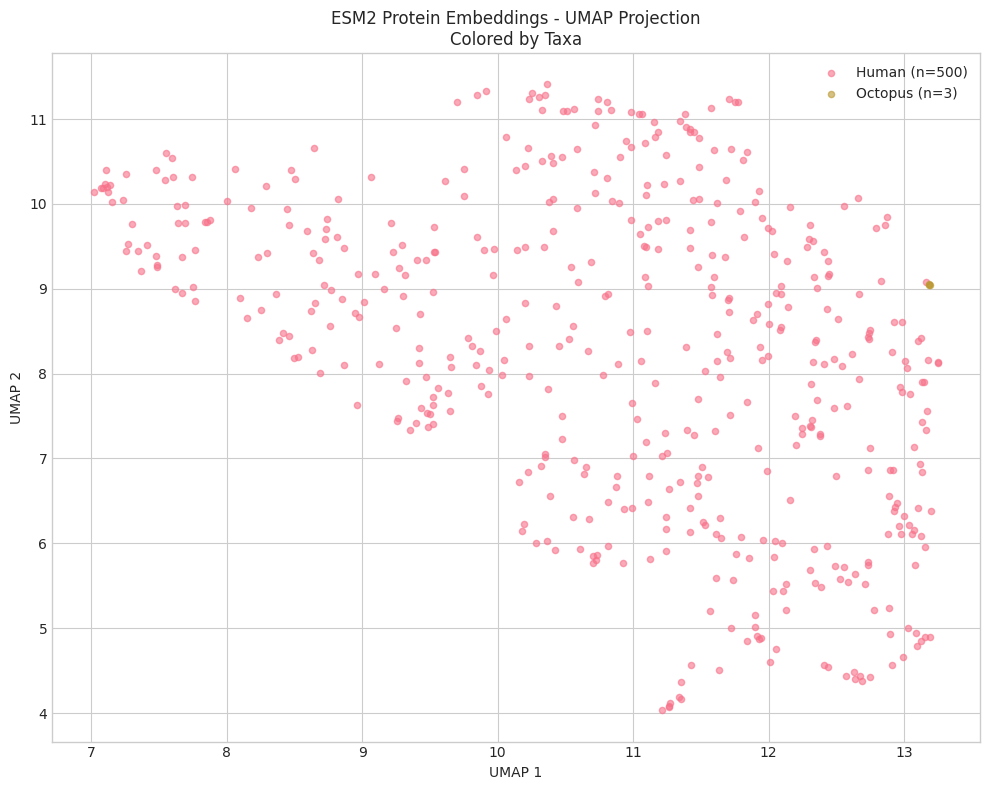

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

for taxon_name, group in sample_df.groupby('taxon_name'):
    ax.scatter(
        group['umap_x'], 
        group['umap_y'],
        label=f"{taxon_name} (n={len(group)})",
        alpha=0.6,
        s=20
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('ESM2 Protein Embeddings - UMAP Projection\nColored by Taxa')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## Visualization: Colored by HOG (Root Level)

In [11]:
# Analyze HOG distribution
print("HOG coverage in sample:")
has_hog = sample_df['hog_id'].notna()
print(f"  Proteins with HOG: {has_hog.sum()} ({100*has_hog.mean():.1f}%)")
print(f"  Unique HOGs: {sample_df['hog_id'].nunique()}")
print(f"  Unique root HOGs: {sample_df['roothog_id'].nunique()}")

# Find most common root HOGs
top_roothogs = sample_df['roothog_id'].value_counts().head(10)
print(f"\nTop 10 root HOGs:")
print(top_roothogs)

HOG coverage in sample:
  Proteins with HOG: 455 (90.5%)
  Unique HOGs: 338
  Unique root HOGs: 324

Top 10 root HOGs:
roothog_id
0.0          116
801468.0       6
794303.0       3
792940.0       3
777987.0       2
1028112.0      2
805243.0       2
793048.0       2
802754.0       2
793167.0       2
Name: count, dtype: int64


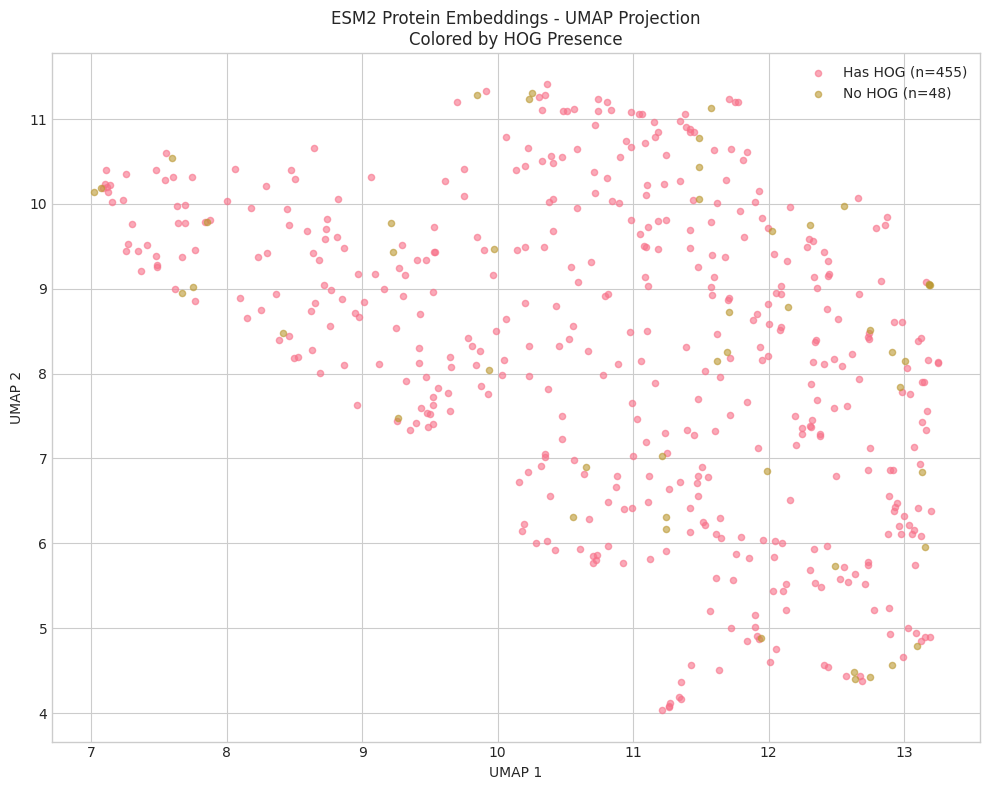

In [12]:
# Plot: HOG presence (has HOG vs no HOG)
fig, ax = plt.subplots(figsize=(10, 8))

sample_df['has_hog'] = sample_df['hog_id'].notna().map({True: 'Has HOG', False: 'No HOG'})

for hog_status, group in sample_df.groupby('has_hog'):
    ax.scatter(
        group['umap_x'], 
        group['umap_y'],
        label=f"{hog_status} (n={len(group)})",
        alpha=0.6,
        s=20
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('ESM2 Protein Embeddings - UMAP Projection\nColored by HOG Presence')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

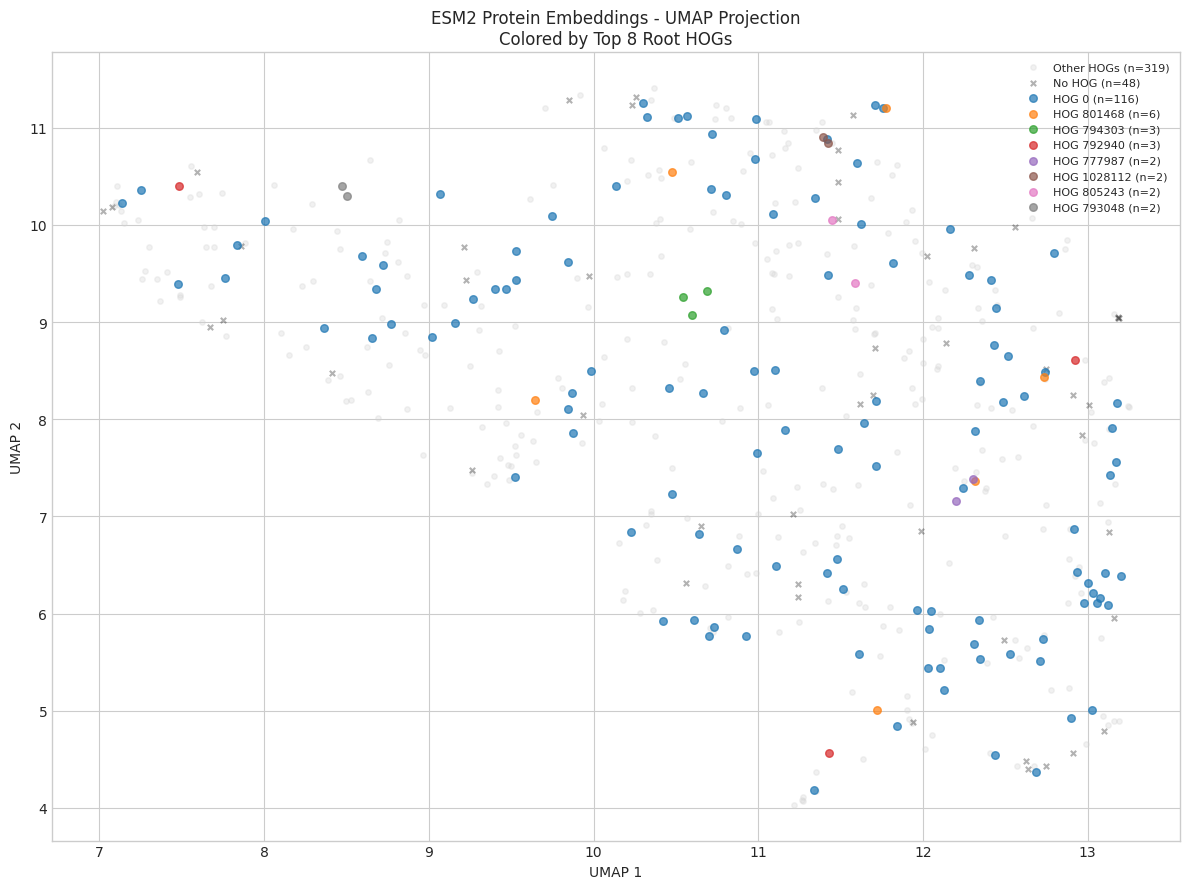

In [13]:
# Plot: Top N root HOGs
TOP_N_HOGS = 8
top_hog_ids = sample_df['roothog_id'].value_counts().head(TOP_N_HOGS).index.tolist()

fig, ax = plt.subplots(figsize=(12, 9))

# Plot "other" HOGs first (background)
other_mask = ~sample_df['roothog_id'].isin(top_hog_ids) & sample_df['roothog_id'].notna()
other_df = sample_df[other_mask]
ax.scatter(
    other_df['umap_x'], 
    other_df['umap_y'],
    label=f'Other HOGs (n={len(other_df)})',
    alpha=0.3,
    s=15,
    c='lightgray'
)

# Plot no-HOG proteins
no_hog_df = sample_df[sample_df['roothog_id'].isna()]
if len(no_hog_df) > 0:
    ax.scatter(
        no_hog_df['umap_x'], 
        no_hog_df['umap_y'],
        label=f'No HOG (n={len(no_hog_df)})',
        alpha=0.3,
        s=15,
        c='black',
        marker='x'
    )

# Plot top HOGs with distinct colors
colors = plt.cm.tab10.colors
for i, hog_id in enumerate(top_hog_ids):
    hog_df = sample_df[sample_df['roothog_id'] == hog_id]
    ax.scatter(
        hog_df['umap_x'], 
        hog_df['umap_y'],
        label=f'HOG {int(hog_id)} (n={len(hog_df)})',
        alpha=0.7,
        s=30,
        c=[colors[i % len(colors)]]
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f'ESM2 Protein Embeddings - UMAP Projection\nColored by Top {TOP_N_HOGS} Root HOGs')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## Combined Visualization: Taxa + HOG

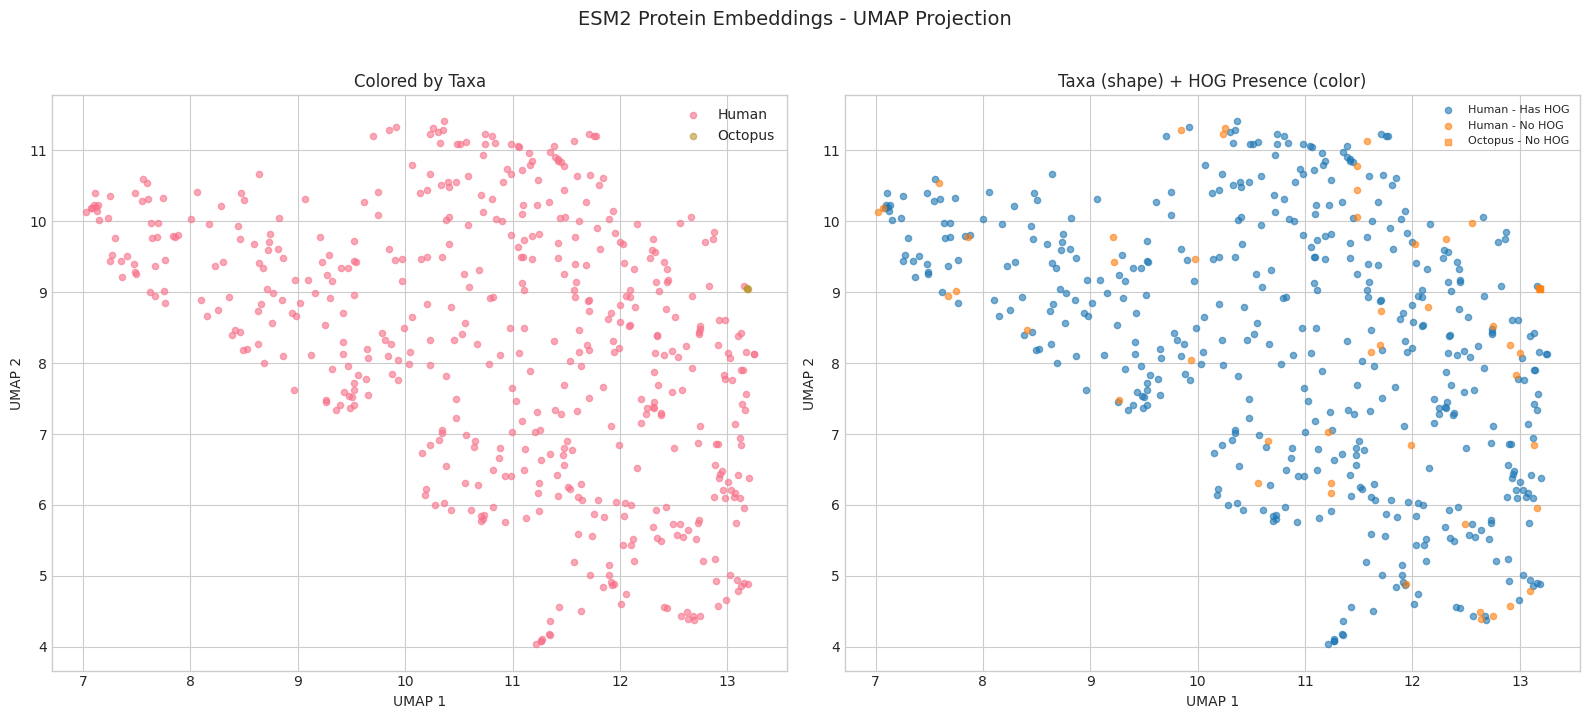

In [14]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Colored by taxa
ax = axes[0]
for taxon_name, group in sample_df.groupby('taxon_name'):
    ax.scatter(
        group['umap_x'], 
        group['umap_y'],
        label=taxon_name,
        alpha=0.6,
        s=20
    )
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Colored by Taxa')
ax.legend(loc='best')

# Right: Colored by HOG presence, shaped by taxa
ax = axes[1]
markers = {'Human': 'o', 'Octopus': 's', 'Zebrafish': 's'}  # Circle for human, square for other
colors = {'Has HOG': 'tab:blue', 'No HOG': 'tab:orange'}

for (taxon, hog_status), group in sample_df.groupby(['taxon_name', 'has_hog']):
    ax.scatter(
        group['umap_x'], 
        group['umap_y'],
        label=f"{taxon} - {hog_status}",
        alpha=0.6,
        s=20,
        marker=markers.get(taxon, 'o'),
        c=colors[hog_status]
    )
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Taxa (shape) + HOG Presence (color)')
ax.legend(loc='best', fontsize=8)

plt.suptitle('ESM2 Protein Embeddings - UMAP Projection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Shared HOGs Between Taxa

In [15]:
# Find HOGs shared between taxa
taxa_names = list(TARGET_TAXA.values())
taxa_hogs = {}
for taxon in taxa_names:
    taxon_df = sample_df[sample_df['taxon_name'] == taxon]
    taxa_hogs[taxon] = set(taxon_df['roothog_id'].dropna().unique())
    print(f"{taxon}: {len(taxa_hogs[taxon])} unique root HOGs")

# Find intersection
shared_hogs = set.intersection(*taxa_hogs.values())
print(f"\nShared root HOGs: {len(shared_hogs)}")

# Show some shared HOGs
if shared_hogs:
    print(f"Sample shared HOGs: {list(shared_hogs)[:10]}")

Human: 324 unique root HOGs
Octopus: 0 unique root HOGs

Shared root HOGs: 0


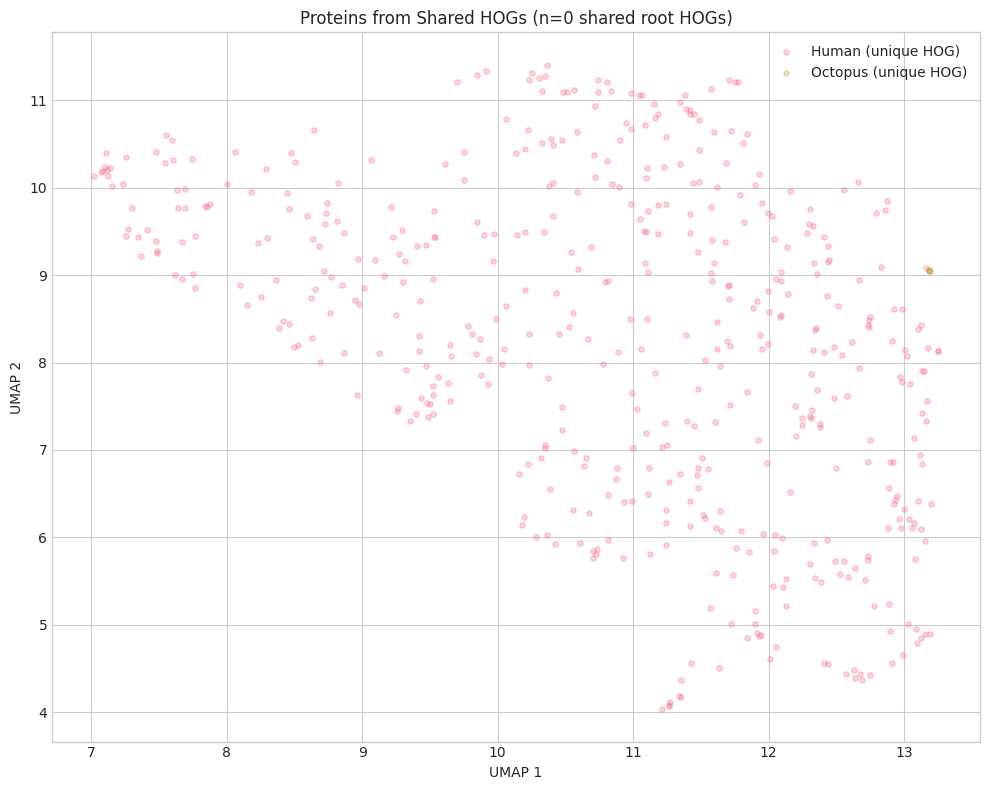

In [16]:
# Highlight proteins from shared HOGs
fig, ax = plt.subplots(figsize=(10, 8))

sample_df['is_shared_hog'] = sample_df['roothog_id'].isin(shared_hogs)

# Plot non-shared first
non_shared = sample_df[~sample_df['is_shared_hog']]
for taxon, group in non_shared.groupby('taxon_name'):
    ax.scatter(
        group['umap_x'], group['umap_y'],
        alpha=0.3, s=15, label=f"{taxon} (unique HOG)"
    )

# Plot shared HOGs with emphasis
shared = sample_df[sample_df['is_shared_hog']]
for taxon, group in shared.groupby('taxon_name'):
    ax.scatter(
        group['umap_x'], group['umap_y'],
        alpha=0.8, s=40, marker='*', label=f"{taxon} (shared HOG)"
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f'Proteins from Shared HOGs (n={len(shared_hogs)} shared root HOGs)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## Summary Statistics

In [17]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nDataset: {data_path}")
print(f"Total proteins in dataset: {df['EntryID'].nunique():,}")
print(f"\nSampled proteins: {len(sample_df):,}")
for taxon in taxa_names:
    count = (sample_df['taxon_name'] == taxon).sum()
    hog_count = sample_df[sample_df['taxon_name'] == taxon]['hog_id'].notna().sum()
    print(f"  {taxon}: {count} proteins, {hog_count} with HOG ({100*hog_count/count:.1f}%)")

print(f"\nHOG Statistics:")
print(f"  Unique root HOGs in sample: {sample_df['roothog_id'].nunique()}")
print(f"  Shared between taxa: {len(shared_hogs)}")
print(f"\nEmbedding: ESM2 (facebook/esm2_t33_650M_UR50D), {len(embedding_cols)} dimensions")
print(f"UMAP: n_neighbors=15, min_dist=0.1, metric=cosine")

SUMMARY

Dataset: ../assets/proteins/datasets/cafa3_merged/cafa3_with_embeddings.feather
Total proteins in dataset: 142,246

Sampled proteins: 503
  Human: 500 proteins, 455 with HOG (91.0%)
  Octopus: 3 proteins, 0 with HOG (0.0%)

HOG Statistics:
  Unique root HOGs in sample: 324
  Shared between taxa: 0

Embedding: ESM2 (facebook/esm2_t33_650M_UR50D), 1280 dimensions
UMAP: n_neighbors=15, min_dist=0.1, metric=cosine
